<a href="https://colab.research.google.com/github/SakshyamKarki/ML/blob/master/Clustering_and_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KMeans**

In [ ]:
!pip install kagglehub==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [ ]:
import kagglehub
path = kagglehub.dataset_download("imanjowkar/clustering")

Using Colab cache for faster access to the 'clustering' dataset.


In [ ]:
import pandas as pd

df = pd.read_csv(f"{path}/Clustering.csv")

In [ ]:
df.head()

,Unnamed: 0,x,y
0,1,3.367596,3.536694
1,2,2.667870,4.479919
2,3,1.344171,3.282591
3,4,1.389414,4.683227
4,5,1.644644,4.320822


In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
df.describe()

,x,y
count,190.000000,190.000000
mean,4.721308,6.345303
std,3.294171,3.614820
min,-1.428115,-0.476742
25%,1.713220,3.126976
50%,3.462090,4.697728
75%,7.858967,9.802251
max,10.674577,12.894445


In [ ]:
df.isna().sum()

,0
x,0
y,0


In [ ]:
X = df[['x']]
y = df[['y']]

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters = 2)
kmeans.fit(X, y)
labels = kmeans.labels_

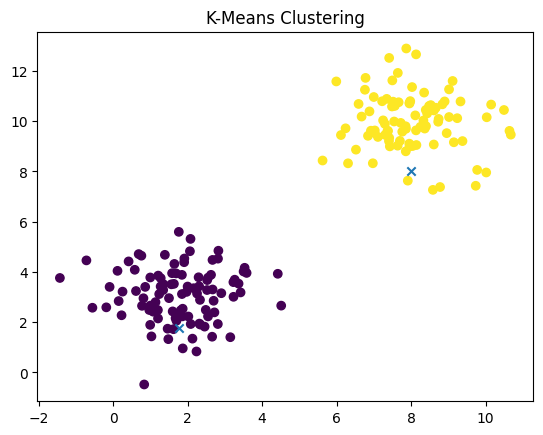

In [ ]:
plt.scatter(X, y, c=labels)
plt.scatter(kmeans.cluster_centers_[:], kmeans.cluster_centers_[:], marker='x')
plt.title("K-Means Clustering")
plt.show()

# **Hierarchial Clustering**

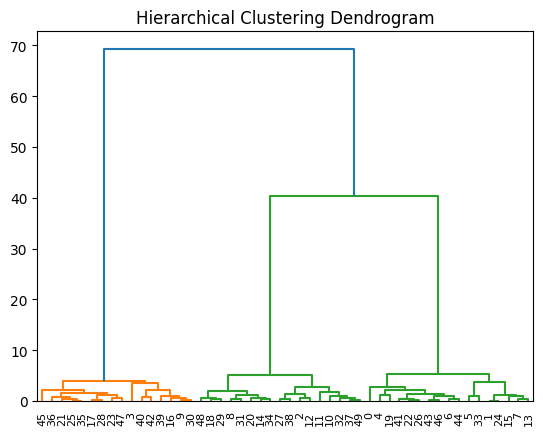

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# **DBSCAN**

In [ ]:
X = df[['x']]
y = df[['y']]

X,y

(            x
 0    3.367596
 1    2.667870
 2    1.344171
 3    1.389414
 4    1.644644
 ..        ...
 185  8.610144
 186  6.775686
 187  7.023465
 188  6.115584
 189  7.868889
 
 [190 rows x 1 columns],
              y
 0     3.536694
 1     4.479919
 2     3.282591
 3     4.683227
 4     4.320822
 ..         ...
 185  10.429247
 186  11.724382
 187   9.632056
 188   9.449803
 189  12.894445
 
 [190 rows x 1 columns])

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps = 0.7, min_samples=15)
labels = db.fit_predict(X, y)

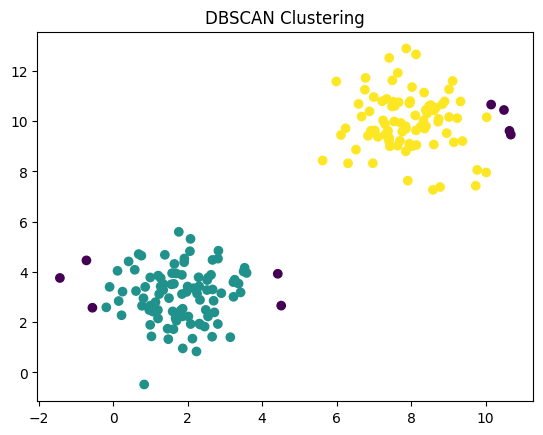

In [ ]:
plt.scatter(X, y, c=labels)
plt.title("DBSCAN Clustering")
plt.show()

# **PCA**

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/california_housing_train.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [3]:
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925208,-0.114250,0.047010,0.071802,0.101674,0.059628,-0.015485,-0.044982
latitude,-0.925208,1.000000,0.016454,-0.038773,-0.069373,-0.111261,-0.074902,-0.080303,-0.144917
housing_median_age,-0.114250,0.016454,1.000000,-0.360984,-0.320434,-0.295890,-0.302754,-0.115932,0.106758
total_rooms,0.047010,-0.038773,-0.360984,1.000000,0.928403,0.860170,0.919018,0.195383,0.130991
total_bedrooms,0.071802,-0.069373,-0.320434,0.928403,1.000000,0.881169,0.980920,-0.013495,0.045783
population,0.101674,-0.111261,-0.295890,0.860170,0.881169,1.000000,0.909247,-0.000638,-0.027850
households,0.059628,-0.074902,-0.302754,0.919018,0.980920,0.909247,1.000000,0.007644,0.061031
median_income,-0.015485,-0.080303,-0.115932,0.195383,-0.013495,-0.000638,0.007644,1.000000,0.691871
median_house_value,-0.044982,-0.144917,0.106758,0.130991,0.045783,-0.027850,0.061031,0.691871,1.000000


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df[['housing_median_age', 'total_rooms', 'median_income', 'median_house_value']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Explained variance ratio: [0.44555063 0.32893067]


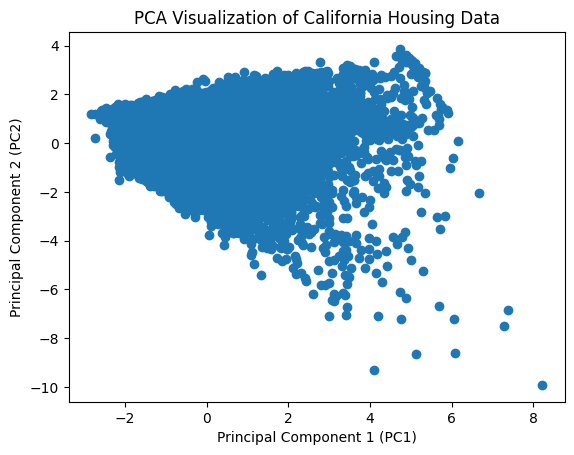

In [5]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Visualization of California Housing Data")
plt.show()

##  **t-*SNE***

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,
            perplexity=30,
            learning_rate=100
            )

X_tsne = tsne.fit_transform(X_scaled)

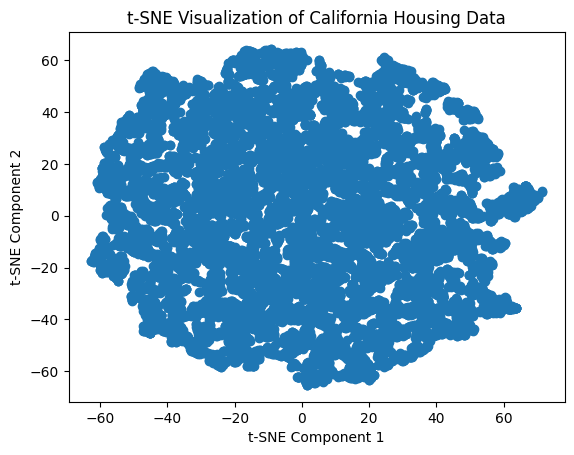

In [7]:
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of California Housing Data")
plt.show()